# Get CMB fisher matrix

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
#load modules
import numpy as np, sys, os
sys.path.append('modules/')
import misc, sne_cmb_fisher_tools
from astropy import constants as const
from astropy import units as u
from astropy import coordinates as coord
from astropy.cosmology import FlatLambdaCDM
import healpy as H
from pylab import *

In [25]:
rcParams['figure.dpi'] = 150
rcParams['figure.facecolor'] = 'white'


In [27]:
#CMB specs
which_spectra = 'lensed_scalar'
#which_spectra = 'unlensed_scalar'
delta_l = 50 ##100

#params
paramfile = 'data/params.ini'
cmb_params = ['As', 'h', 'ns', 'omch2', 'ombh2', 'tau', 'ws', 'wa', 'mnu', 'neff', 'nrun']
if 'h' in cmb_params:
    thetastar_or_cosmomctheta_or_h = 'h'
elif 'thetastar' in cmb_params:
    thetastar_or_cosmomctheta_or_h = 'thetastar'
elif 'cosmomc_theta' in cmb_params:
    thetastar_or_cosmomctheta_or_h = 'cosmomc_theta'


#experiments
#lmin_t, lmin_p, lmax_t, lmax_p = 300, 300, 3000, 5000
lmin_t, lmin_p, lmax_t, lmax_p = 300, 300, 3500, 3500
lmin_phi, lmax_phi = 30, 3500 ##4000

# lmin_t, lmin_p, lmax_t, lmax_p = 300, 300, 3000, 3000
# lmin_phi, lmax_phi = 30, 3000 ##4000

##add_lensing = True
exp_dic = {'sobaseline': 
                   {'label': 'SO-Baseline', 
                    'fsky': 0.4, 
                    'ilcfile': 'data/cmb/SO/sobaseline_ilc_cmb_27-39-93-145-225-280_TT-EE_fsky-1_-1years.npy',
                    'lensingfile': 'data/cmb/lensing/sobaseline_ilc_cmb_27-39-93-145-225-280_TT-EE_fsky-1_-1years_lmin300_lmax4000_lmaxtt3500.npy',
                    'color': 'royalblue',
                    'lmin_t': lmin_t,
                    'lmin_p': lmin_p,
                    'lmax_t': lmax_t,
                    'lmax_p': lmax_p,
                    'lmin_phi': lmin_phi,
                    'lmax_phi': lmax_phi,
                   },
                'sogoal': 
                   {'label': 'SO-Goal', 
                    'fsky': 0.4, 
                    'ilcfile': 'data/cmb/SO/sogoal_ilc_cmb_27-39-93-145-225-280_TT-EE_fsky-1_-1years.npy',
                    'lensingfile': 'data/cmb/lensing/sogoal_ilc_cmb_27-39-93-145-225-280_TT-EE_fsky-1_-1years_lmin300_lmax4000_lmaxtt3500.npy',
                    'color': 'darkorange',
                    'lmin_t': lmin_t,
                    'lmin_p': lmin_p,
                    'lmax_t': lmax_t,
                    'lmax_p': lmax_p,
                    'lmin_phi': lmin_phi,
                    'lmax_phi': lmax_phi,
                   },               
                'cmbs4': 
                   {'label': 'CMB-S4', 
                    'fsky': 0.57, 
                    'ilcfile': 'data/cmb/cmbs4/s4wide_202310xx_pbdr_config/s4wide_202310xx_pbdr_config_ilc_galaxy0_27-39-93-145-225-278_TT-EE_lmax12000_for7years.npy',
                    'lensingfile': 'data/cmb/lensing/s4wide_202310xx_pbdr_config_ilc_cmb_27-39-93-145-225-278_TT-EE_fsky-1_-1years_lmin300_lmax4000_lmaxtt3500.npy',
                    'color': 'darkgreen',
                    'lmin_t': lmin_t,
                    'lmin_p': lmin_p,
                    'lmax_t': lmax_t,
                    'lmax_p': lmax_p,
                    'lmin_phi': lmin_phi,
                    'lmax_phi': lmax_phi,
                   }, 
                'spt3g_wide': 
                   {'label': 'SPT-3G: Wide (6000 sq. deg)', 
                    'fsky': 0.14, 
                    'ilcfile': 'data/cmb/spt/spt_proposal_2023_ilc_cmb_90-150-220_TT-EE_fsky6000_1years.npy',
                    'lensingfile': 'data/cmb/lensing/spt_proposal_2023_ilc_cmb_90-150-220_TT-EE_fsky6000_1years_lmin300_lmax4000_lmaxtt3500.npy',
                    'color': 'orangered',
                    'lmin_t': lmin_t,
                    'lmin_p': lmin_p,
                    'lmax_t': lmax_t,
                    'lmax_p': lmax_p,
                    'lmin_phi': lmin_phi,
                    'lmax_phi': lmax_phi,
                   }, 
                'spt3g+_wide': 
                   {'label': 'SPT-3G+: Wide (6000 sq. deg)', 
                    'fsky': 0.14, 
                    'ilcfile': 'data/cmb/spt/spt3g+wide_plus_spt3gwide_202505xx_ilc_cmb_90-150-220_TT-EE_fsky6000_1years.npy',
                    'lensingfile': None,
                    'color': 'black',
                    'lmin_t': lmin_t,
                    'lmin_p': lmin_p,
                    'lmax_t': lmax_t,
                    'lmax_p': lmax_p,
                    'lmin_phi': lmin_phi,
                    'lmax_phi': lmax_phi,
                   },
                'cmbs4_ideal':
                   {'label': 'CMB-S4', 
                    'fsky': 0.57, 
                    'ilcfile': None,
                    'lensingfile': None,
                    'noiseval': 1., #uk-arcmin
                    'beamval_arcmins': 1.4, #arcmins
                    'color': 'black',
                    'lmin_t': 30,
                    'lmin_p': 30,
                    'lmax_t': 3500,
                    'lmax_p': 5000,
                    'lmin_phi': 30,
                    'lmax_phi': 5000,
                   }, 
              }

exp_arr = list( exp_dic.keys() )

In [28]:
#get the params as dict
print('\nget the params as dict')
param_dict = misc.get_param_dict(paramfile)
param_dict['omega_m'] = param_dict['omch2'] / param_dict['h']**2.
print(param_dict.keys())

cmb_fd = 'results/cmb/'
if not os.path.exists( cmb_fd ): os.system('mkdir -p %s' %(cmb_fd))
cmb_spec_fname = '%s/camb_cl_%s' %(cmb_fd, which_spectra)
cmb_spec_deriv_fname = '%s/camb_cl_%s_deriv' %(cmb_fd, which_spectra)
if delta_l != 1:
    cmb_spec_fname = '%s_deltal%s' %(cmb_spec_fname, delta_l)
    cmb_spec_deriv_fname = '%s_deltal%s' %(cmb_spec_fname, delta_l)
cmb_spec_fname = '%s.npy' %(cmb_spec_fname)
cmb_spec_deriv_fname = '%s.npy' %(cmb_spec_fname)
    
print('\nget CAMB cl and derivatives')

if os.path.exists( cmb_spec_fname ) and os.path.exists( cmb_spec_deriv_fname ):
    print('\t\tPicking cl_dic and cl_deriv_dic from alread computed files: %s and %s' %(cmb_spec_fname, cmb_spec_deriv_fname))
    cmb_cl_dic = np.load( cmb_spec_fname, allow_pickle = True ).item()
    cmb_cl_deriv_dic = np.load( cmb_spec_deriv_fname, allow_pickle = True ).item()
else:
    pars, cmb_cl_dic, cmb_cl_deriv_dic = sne_cmb_fisher_tools.get_camb_cl_and_derivatives(cmb_params, param_dict, which_spectra = which_spectra, delta_l = delta_l, thetastar_or_cosmomctheta_or_h = thetastar_or_cosmomctheta_or_h)
    print('\t\tDumping cl_dic and cl_deriv_dic into: %s and %s' %(cmb_spec_fname, cmb_spec_deriv_fname))
    np.save( cmb_spec_fname, cmb_cl_dic )
    np.save( cmb_spec_deriv_fname, cmb_cl_deriv_dic )
    
print(cmb_cl_dic.keys(), cmb_cl_deriv_dic.keys())
els = cmb_cl_dic['els']
print( 'els = ', els[:10], els.shape )
print( cmb_cl_deriv_dic['As']['TT'].shape )



get the params as dict
dict_keys(['zlss', 'tcmb', 'h', 'thetastar', 'ombh2', 'omch2', 'neff', 'As', 'logA', 'omk', 'tau', 'ns', 'r', 'ws', 'wa', 'YHe', 'Alens', 'Aphiphi', 'nrun', 'mnu', 'num_nu_massive', 'lmin_t', 'lmin_p', 'M', 'b', 'alpha', 'beta', 'gamma', 'lens_potential_accuracy', 'min_l_limit', 'max_l_limit', 'max_l_tensor', 'max_eta_k', 'max_eta_k_tensor', 'pivot_scalar', 'pivot_tensor', 'AccuracyBoost', 'lAccuracyBoost', 'lSampleBoost', 'accurate_polarization', 'accurate_reionization', 'do_tensor_neutrinos', 'do_late_rad_truncation', 'number_of_threads', 'omega_m'])

get CAMB cl and derivatives

Get fiducial CAMB power spectra. Spectra = lensed_scalar
set CAMB cosmology and get power spectra in uK^2 units

Get derivatives of CAMB power spectra. Spectra = lensed_scalar
	param for derivative = As
		values: fid=2.098e-09, low=2.07702e-09, high=2.11898e-09, step=2.098e-11
set CAMB cosmology and get power spectra in uK^2 units
set CAMB cosmology and get power spectra in uK^2 units

set CAMB cosmology and get power spectra in uK^2 units
			TT: [ 1.17181487e+02 -1.41782515e+00  5.82261587e-01  3.70017510e-01
  1.02663965e-01 -1.21875614e-01 -1.91522805e-01 -1.23845046e-01
 -1.90924072e-02  3.61257064e-02  2.58634062e-02 -9.34318974e-03
 -2.51280272e-02 -1.11885574e-02  1.13702118e-02  1.83599525e-02
  5.13902173e-03 -1.39808008e-02 -2.25478761e-02 -1.63738467e-02
 -3.94719946e-03  3.75272083e-03  2.76020952e-03 -2.73204408e-03
 -6.21449907e-03 -4.92108762e-03 -1.04502550e-03  1.52199445e-03
  9.58490224e-04 -1.48588072e-03 -3.32110034e-03 -3.18205678e-03
 -1.63196911e-03 -1.79032615e-04  1.92426894e-04 -3.52984715e-04
 -9.82089105e-04 -1.06835791e-03 -6.37904792e-04 -1.52034491e-04
  1.24868642e-06 -1.92196153e-04 -4.63491290e-04 -5.55506635e-04
 -4.24231731e-04 -2.12108836e-04 -8.15834901e-05 -8.27351003e-05
 -1.49622754e-04 -1.88985618e-04 -1.62687443e-04 -1.00493873e-04
 -5.46710824e-05 -5.05320979e-05 -7.36080538e-05 -9.24644452e-05
 -8.82330787e-05 -6.54936341

set CAMB cosmology and get power spectra in uK^2 units
			TT: [-3.14384216e+00  9.08186626e-02  6.08044978e-02  4.35357199e-02
  1.50456771e-02 -8.13301067e-03 -1.62474932e-02 -1.09922954e-02
 -1.73200084e-03  3.32489141e-03  2.45319470e-03 -7.67681363e-04
 -2.26923239e-03 -1.02324774e-03  1.08321753e-03  1.80146235e-03
  6.33303715e-04 -1.15001199e-03 -2.01516912e-03 -1.51576277e-03
 -3.89240533e-04  3.47856874e-04  2.90263569e-04 -2.09222949e-04
 -5.51467431e-04 -4.56713920e-04 -1.04649809e-04  1.46814302e-04
  1.12567452e-04 -1.08926546e-04 -2.90141464e-04 -2.93818748e-04
 -1.59334589e-04 -2.24858972e-05  1.96136875e-05 -2.62194259e-05
 -8.62027444e-05 -9.92680726e-05 -6.26456149e-05 -1.67180203e-05
  7.97630399e-07 -1.48449421e-05 -4.05525782e-05 -5.15938647e-05
 -4.16450663e-05 -2.24525091e-05 -9.33835152e-06 -8.24836585e-06
 -1.40873616e-05 -1.82166921e-05 -1.64054760e-05 -1.07873953e-05
 -6.15810321e-06 -5.27730378e-06 -7.21836157e-06 -9.14511804e-06
 -9.07331881e-06 -7.14370474

set CAMB cosmology and get power spectra in uK^2 units
			TT: [-2.06575280e-01  6.03855450e-02  4.75642604e-02  3.35618038e-02
  3.25316006e-02  3.43583409e-02  2.89531346e-02  1.63585446e-02
  3.93353677e-03 -1.90418021e-03 -9.15874332e-04  2.26980181e-03
  3.16552077e-03  9.85671236e-04 -1.83814791e-03 -2.69601741e-03
 -1.17367098e-03  1.06408131e-03  2.13415747e-03  1.53203090e-03
  1.89790323e-04 -6.54143263e-04 -5.31869599e-04  1.01681634e-04
  5.12765237e-04  3.78740696e-04 -5.83186235e-05 -3.51936823e-04
 -2.83760964e-04  1.10682395e-05  2.45854699e-04  2.55428300e-04
  9.63381504e-05 -6.00512470e-05 -9.68221746e-05 -2.81981727e-05
  5.16877434e-05  6.93014351e-05  2.56116010e-05 -2.66753873e-05
 -4.15539550e-05 -1.58457904e-05  1.99098036e-05  3.53351308e-05
  2.43287545e-05  2.86955125e-06 -1.00249649e-05 -8.02855528e-06
  1.56206087e-06  7.92940481e-06  6.46733672e-06  5.24964981e-07
 -3.76118852e-06 -3.29522125e-06  3.44624826e-07  3.49583682e-06
  3.88912745e-06  1.99688981

set CAMB cosmology and get power spectra in uK^2 units
			TT: [ 1.11150297e+03 -1.21010066e+01  2.26349137e+00  9.46517970e-01
  4.78098856e-01  2.02696825e-01  6.73330186e-02  1.68094030e-02
  4.23839471e-03  2.54370021e-03  2.03400393e-03  1.46557850e-03
  1.27624698e-03  1.36458541e-03  1.40680856e-03  1.34883460e-03
  1.31973440e-03  1.36458630e-03  1.40279224e-03  1.36966707e-03
  1.29445749e-03  1.23989888e-03  1.21488530e-03  1.17404207e-03
  1.08566077e-03  9.74554061e-04  8.92710273e-04  8.60669690e-04
  8.46988484e-04  8.03125755e-04  7.11613758e-04  5.99020636e-04
  5.07181077e-04  4.55932109e-04  4.31991710e-04  4.08020615e-04
  3.68696257e-04  3.19960391e-04  2.77799569e-04  2.51372638e-04
  2.36273869e-04  2.21145788e-04  1.98659533e-04  1.70550758e-04
  1.44022056e-04  1.24659523e-04  1.12515850e-04  1.03617784e-04
  9.41534429e-05  8.32464261e-05  7.25392804e-05  6.39014100e-05
  5.76740068e-05  5.27106353e-05  4.76443646e-05  4.20020294e-05
  3.63054419e-05  3.13747114

...

set CAMB cosmology and get power spectra in uK^2 units
			TT: [-2.61385197e+02  2.64333365e+01  1.72126059e+01  1.44067930e+01
  1.17667221e+01  8.73086660e+00  5.16018522e+00  1.72725088e+00
 -6.37254462e-01 -1.50605730e+00 -1.22906841e+00 -5.78141975e-01
 -1.63171120e-01 -1.16922369e-01 -2.12211193e-01 -1.99070143e-01
 -3.36612511e-02  1.46644181e-01  2.00136629e-01  1.12516816e-01
 -1.63976750e-02 -8.10573282e-02 -5.60359395e-02  6.86874148e-03
  4.36612256e-02  3.40352344e-02  4.40024180e-03 -9.13901602e-03
  4.84368559e-03  2.96598404e-02  4.22077810e-02  3.44313917e-02
  1.64344321e-02  3.60879224e-03  2.85954086e-03  9.58126218e-03
  1.48416095e-02  1.39542336e-02  9.00529124e-03  5.03202486e-03
  4.87570336e-03  7.36080093e-03  9.35318447e-03  8.88442981e-03
  6.46025432e-03  3.99134580e-03  2.89284868e-03  3.12806041e-03
  3.68817095e-03  3.69517684e-03  3.05616092e-03  2.28162130e-03
  1.87128058e-03  1.89664929e-03  2.05938306e-03  2.03560189e-03
  1.74294616e-03  1.33828722

set CAMB cosmology and get power spectra in uK^2 units
			TT: [-2.81739388e+02 -2.31803255e+00 -5.56683511e+00 -4.16311444e+00
 -3.32362627e+00 -2.56202448e+00 -1.71060561e+00 -8.87867604e-01
 -3.20112054e-01 -1.08891831e-01 -1.47788099e-01 -2.28021829e-01
 -2.07489780e-01 -9.16193380e-02  2.00166861e-02  4.62112817e-02
 -9.40018307e-03 -7.98493411e-02 -1.03679109e-01 -7.23712493e-02
 -2.28210647e-02  4.59423071e-03 -8.46955459e-04 -2.03823277e-02
 -2.98296884e-02 -2.11642397e-02 -4.59059992e-03  5.12005823e-03
  2.33558466e-03 -7.05023149e-03 -1.34143823e-02 -1.21666533e-02
 -6.02949353e-03 -7.82031875e-04  2.36062475e-04 -1.94515593e-03
 -4.08535047e-03 -4.03649467e-03 -2.17242736e-03 -3.34795388e-04
  1.15650621e-04 -7.07529158e-04 -1.71028614e-03 -1.96729631e-03
 -1.40739829e-03 -6.19189507e-04 -1.91252193e-04 -2.51719733e-04
 -5.12932560e-04 -6.31410693e-04 -4.99541477e-04 -2.57663914e-04
 -1.03155097e-04 -1.11855898e-04 -2.10953938e-04 -2.79051319e-04
 -2.55237277e-04 -1.68091316

set CAMB cosmology and get power spectra in uK^2 units
			TT: [-1.88722325e+01 -6.73689145e+00 -3.14632732e+00 -2.31696621e+00
 -1.67108305e+00 -1.04466987e+00 -5.43867073e-01 -2.47463420e-01
 -1.33141069e-01 -1.16306738e-01 -1.17625492e-01 -1.02016902e-01
 -7.45875944e-02 -5.32942125e-02 -4.63268490e-02 -4.78701180e-02
 -4.74499413e-02 -4.00015170e-02 -2.82396190e-02 -1.80558496e-02
 -1.29118484e-02 -1.19609883e-02 -1.21074537e-02 -1.10770924e-02
 -8.77485827e-03 -6.47077926e-03 -5.20819757e-03 -4.96469977e-03
 -4.97608272e-03 -4.57179413e-03 -3.67762297e-03 -2.68702172e-03
 -2.00329478e-03 -1.72029199e-03 -1.64737767e-03 -1.54667516e-03
 -1.32669059e-03 -1.05564081e-03 -8.45073146e-04 -7.39569266e-04
 -6.98117294e-04 -6.51532553e-04 -5.65013196e-04 -4.54121004e-04
 -3.56270784e-04 -2.94310445e-04 -2.63185607e-04 -2.42439407e-04
 -2.16343420e-04 -1.83479084e-04 -1.52010041e-04 -1.29165661e-04
 -1.15204165e-04 -1.05033407e-04 -9.36807797e-05 -7.99796667e-05
 -6.61616425e-05 -5.49669566

set CAMB cosmology and get power spectra in uK^2 units
			TT: [ 8.09921716e+00 -7.31821126e-02  4.65302816e-02  2.98474829e-02
  8.32356696e-03 -9.74241499e-03 -1.53803097e-02 -9.97644491e-03
 -1.56455538e-03  2.89190518e-03  2.08763141e-03 -7.38493701e-04
 -2.01894700e-03 -9.09334838e-04  9.07102681e-04  1.48322544e-03
  4.32060409e-04 -1.10642881e-03 -1.80742778e-03 -1.32316513e-03
 -3.27002760e-04  2.98029328e-04  2.25597628e-04 -2.13997618e-04
 -4.97781091e-04 -3.98545220e-04 -8.79936435e-05  1.21379961e-04
  7.98107123e-05 -1.15610654e-04 -2.65203065e-04 -2.57012577e-04
 -1.33837560e-04 -1.62658923e-05  1.53021043e-05 -2.75685655e-05
 -7.84917976e-05 -8.64153395e-05 -5.23855980e-05 -1.30531458e-05
 -8.62101347e-09 -1.50837042e-05 -3.70014432e-05 -4.48769813e-05
 -3.47147453e-05 -1.76935640e-05 -6.95289916e-06 -6.79102320e-06
 -1.21004817e-05 -1.53671885e-05 -1.33737504e-05 -8.39002990e-06
 -4.61716499e-06 -4.17935651e-06 -5.99541283e-06 -7.54795783e-06
 -7.26839373e-06 -5.46868995

set CAMB cosmology and get power spectra in uK^2 units
			TT: [ 3.58908695e+01 -4.05283428e-01  1.73413749e-01  1.09809336e-01
  3.05505196e-02 -3.60067455e-02 -5.67158631e-02 -3.67332069e-02
 -5.71277851e-03  1.06809881e-02  7.67960231e-03 -2.74445105e-03
 -7.44379737e-03 -3.33464587e-03  3.35476948e-03  5.45255209e-03
  1.55721984e-03 -4.11056311e-03 -6.67205047e-03 -4.86517050e-03
 -1.18817323e-03  1.10486341e-03  8.24632921e-04 -7.99151127e-04
 -1.83827215e-03 -1.46391074e-03 -3.17258871e-04  4.49128638e-04
  2.89185025e-04 -4.33125990e-04 -9.80837502e-04 -9.45235251e-04
 -4.88542357e-04 -5.64911630e-05  5.68088456e-05 -1.03002531e-04
 -2.90114053e-04 -3.17544478e-04 -1.91046490e-04 -4.65251503e-05
  2.63961404e-07 -5.61794270e-05 -1.36796386e-04 -1.64968461e-04
 -1.26790213e-04 -6.39725131e-05 -2.48202254e-05 -2.46899217e-05
 -4.43968352e-05 -5.62620577e-05 -4.86957249e-05 -3.02912531e-05
 -1.65428864e-05 -1.51225505e-05 -2.18942292e-05 -2.75564162e-05
 -2.64180758e-05 -1.97319023

In [29]:
parent_results_fd = 'results/cmb/fisher/'
if not os.path.exists( parent_results_fd ): os.system('mkdir -p %s' %(parent_results_fd))

'''
#cmb_exp_str = 'experiments--%s' %( '--'.join(exp_arr) )
cmb_params_str = 'params--%s' %( '--'.join(cmb_params) )
lmin_lmax_str = 'lmintp--%s--%s_lmaxtp--%s--%s' %( lmin_t, lmin_p, lmax_t, lmax_p )
cmb_fisher_fname = '%s/cmb_fisher_%s_%s_%s_%s' %(results_fd, which_spectra, cmb_exp_str, lmin_lmax_str, cmb_params_str)
cmb_fisher_fname = '%s.npy' %(cmb_fisher_fname)
print( '\nmaster_fisher_dic_fname = %s' %(cmb_fisher_fname) ); ##sys.exit()
'''
#reqd_exp_arr = ['sobaseline', 'sogoal', 'cmbs4']
#reqd_exp_arr = ['sobaseline', 'spt3g_wide']#, 'spt3g+_wide']
#reqd_exp_arr = ['spt3g_wide']#, 'spt3g+_wide']
reqd_exp_arr = ['cmbs4']#, 'spt3g+_wide']
    
#loop through experiments and compute Fisher
fisher_fname_dic = {}
for expname in reqd_exp_arr:
    
    for add_lensing in range(1):
    
        print( expname )

        curr_results_fd = '%s/%s/' %(parent_results_fd, expname)
        if not os.path.exists( curr_results_fd ): os.system('mkdir -p %s' %(curr_results_fd))

        fsky = exp_dic[expname]['fsky']
        ilcfile = exp_dic[expname]['ilcfile']
        lensingfile = exp_dic[expname]['lensingfile']
        if ilcfile is None:
            noiseval, beamval_arcmins = exp_dic[expname]['noiseval'], exp_dic[expname]['beamval_arcmins']
            assert noiseval is not None and beamval_arcmins is not None
        lmin_t, lmin_p = exp_dic[expname]['lmin_t'], exp_dic[expname]['lmin_p']
        lmax_t, lmax_p = exp_dic[expname]['lmax_t'], exp_dic[expname]['lmax_p']


        cmb_params_str = 'params--%s' %( '--'.join(cmb_params) )
        lmin_lmax_str = 'lmint%s--lminp%s--lmaxt%s--lmaxp%s' %( lmin_t, lmin_p, lmax_t, lmax_p )
        fsky_str = 'fsky%g' %(fsky)
        curr_exp_cmb_fisher_fname = '%s/%s_cmb_fisher_%s_%s_%s_%s' %(curr_results_fd, expname, which_spectra, cmb_params_str, lmin_lmax_str, fsky_str)
        if add_lensing:
            curr_exp_cmb_fisher_fname = '%s_lensinglmin%slmax%s' %(curr_exp_cmb_fisher_fname, lmin_phi, lmax_phi)
        if delta_l != 1:
            curr_exp_cmb_fisher_fname = '%s_deltal%s' %(curr_exp_cmb_fisher_fname, delta_l)
        curr_exp_cmb_fisher_fname = '%s.npy' %(curr_exp_cmb_fisher_fname)

        if add_lensing:
            keyname = '%s_withlensing' %(expname)
        else:
            keyname = expname
        fisher_fname_dic[keyname] = curr_exp_cmb_fisher_fname

        if (0):#os.path.exists( curr_exp_cmb_fisher_fname ): 
            continue

        #ILC / noise
        if ilcfile is not None: 
            ilc_dic = np.load( ilcfile, allow_pickle = True ).item()
            el_ilc, cl_ilc_tt, cl_ilc_pp = ilc_dic['el'], ilc_dic['cl_residual']['TT'], ilc_dic['cl_residual']['EE']
            cl_ilc_te = np.zeros(len(els))
            nl_dic = {}
            nl_dic['TT'] = np.interp(els, el_ilc, cl_ilc_tt)
            nl_dic['EE'] = np.interp(els, el_ilc, cl_ilc_pp)
        else:
            noiseval_t, noiseval_p = noiseval, np.sqrt(2.) * noiseval
            delta_T_radians = noiseval_t * np.radians(1./60.)
            delta_P_radians = noiseval_p * np.radians(1./60.)
            nl_tt = np.tile( delta_T_radians**2., len( els ) )
            nl_pp = np.tile( delta_T_radians**2., len( els ) ) 
            bl = H.gauss_beam( np.radians(beamval_arcmins/60.), lmax = len(els)-1)
            nl_tt = nl_tt / bl**2.
            nl_pp = nl_pp / bl**2.
            nl_dic = {}
            nl_dic['TT'] = nl_tt
            nl_dic['EE'] = nl_pp
        
        #signal
        cl_dic = {}
        cl_dic['TT'] = cmb_cl_dic['TT']
        cl_dic['EE'] = cmb_cl_dic['EE']
        cl_dic['TE'] = cmb_cl_dic['TE']
        if add_lensing and lensingfile is not None:
            lensing_dic = np.load( lensingfile, allow_pickle = True, encoding = 'latin1' ).item()
            el_, nl_mv, clkk = lensing_dic['els'], lensing_dic['Nl_MV'], lensing_dic['cl_kk']
            nl_mv = np.interp(els, el_, nl_mv, right = 0.)
            clkk = np.interp(els, el_, clkk, right = 0.)

            nl_dic['PP'] = nl_mv
            #nl_dic['Tphi'] = np.copy(nl_mv) * 0.
            #nl_dic['Ephi'] = np.copy(nl_mv) * 0.

            cl_dic['PP'] = clkk
            #cl_dic['Tphi'] = np.copy(clkk) * 0.
            #cl_dic['Ephi'] = np.copy(clkk) * 0.

            nl_dic['PP'][(els<lmin_phi) & (els>lmax_phi)] = 0.
            cl_dic['PP'][(els<lmin_phi) & (els>lmax_phi)] = 0.

            if (0):
                ax = subplot(111, yscale='log')
                plot(els, cl_dic['PP'])
                plot(els, cmb_cl_dic['PP'])
                plot(els, nl_dic['PP'])
                show(); sys.exit()
        pspectra_to_use = list( cl_dic.keys() )

        #ell ranges
        nl_dic['TT'][(els<lmin_t) & (els>lmax_t)] = 0.
        nl_dic['EE'][(els<lmin_p) & (els>lmax_p)] = 0.
        cl_dic['TT'][(els<lmin_t) & (els>lmax_t)] = 0.
        cl_dic['EE'][(els<lmin_p) & (els>lmax_p)] = 0.
        cl_dic['TE'][(els<lmin_p) & (els>lmax_p)] = 0.

        print(cl_dic['TT'].shape, cl_dic['EE'].shape, cl_dic['TE'].shape, nl_dic['TT'].shape, nl_dic['EE'].shape)

        
        #bandpower errros
        delta_cl_dic = sne_cmb_fisher_tools.get_knox_errors_parent(els, cl_dic, nl_dic, fsky)
        print( delta_cl_dic.keys() ); ##sys.exit()

        #fisher
        cmb_fisher_mat = sne_cmb_fisher_tools.get_cmb_fisher(els, cmb_cl_deriv_dic, delta_cl_dic, cmb_params, pspectra_to_use, lmin_t = lmin_t, lmax_t = lmax_t, lmin_p = lmin_p, lmax_p = lmax_p)
        print( expname, curr_exp_cmb_fisher_fname, np.mean(cmb_fisher_mat), cmb_fisher_mat.shape )

        #store
        #parent_cmb_fisher_dic['exp_dic'] = exp_dic
        op_dic = {}
        op_dic['experiment'] = exp_dic[expname]
        op_dic['fisher_matrix'] = cmb_fisher_mat
        op_dic['params'] = cmb_params
        op_dic['param_dict'] = param_dict    
        np.save( curr_exp_cmb_fisher_fname, op_dic )


cmbs4
(101,) (101,) (101,) (101,) (101,)
TT
EE
TE
dict_keys(['TT', 'EE', 'TE'])
cmbs4 results/cmb/fisher//cmbs4//cmbs4_cmb_fisher_lensed_scalar_params--As--h--ns--omch2--ombh2--tau--ws--wa--mnu--neff--nrun_lmint300--lminp300--lmaxt3500--lmaxp3500_fsky0.57_deltal50.npy 6.580371335254177e+21 (11, 11)


In [30]:
fisher_fname_dic

{'cmbs4': 'results/cmb/fisher//cmbs4//cmbs4_cmb_fisher_lensed_scalar_params--As--h--ns--omch2--ombh2--tau--ws--wa--mnu--neff--nrun_lmint300--lminp300--lmaxt3500--lmaxp3500_fsky0.57_deltal50.npy'}

# Compare binned vs unbinned results

cmbs4_binned_deltal100
cmbs4_binned_deltal50
cmbs4_unbinned


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 900x600 with 0 Axes>

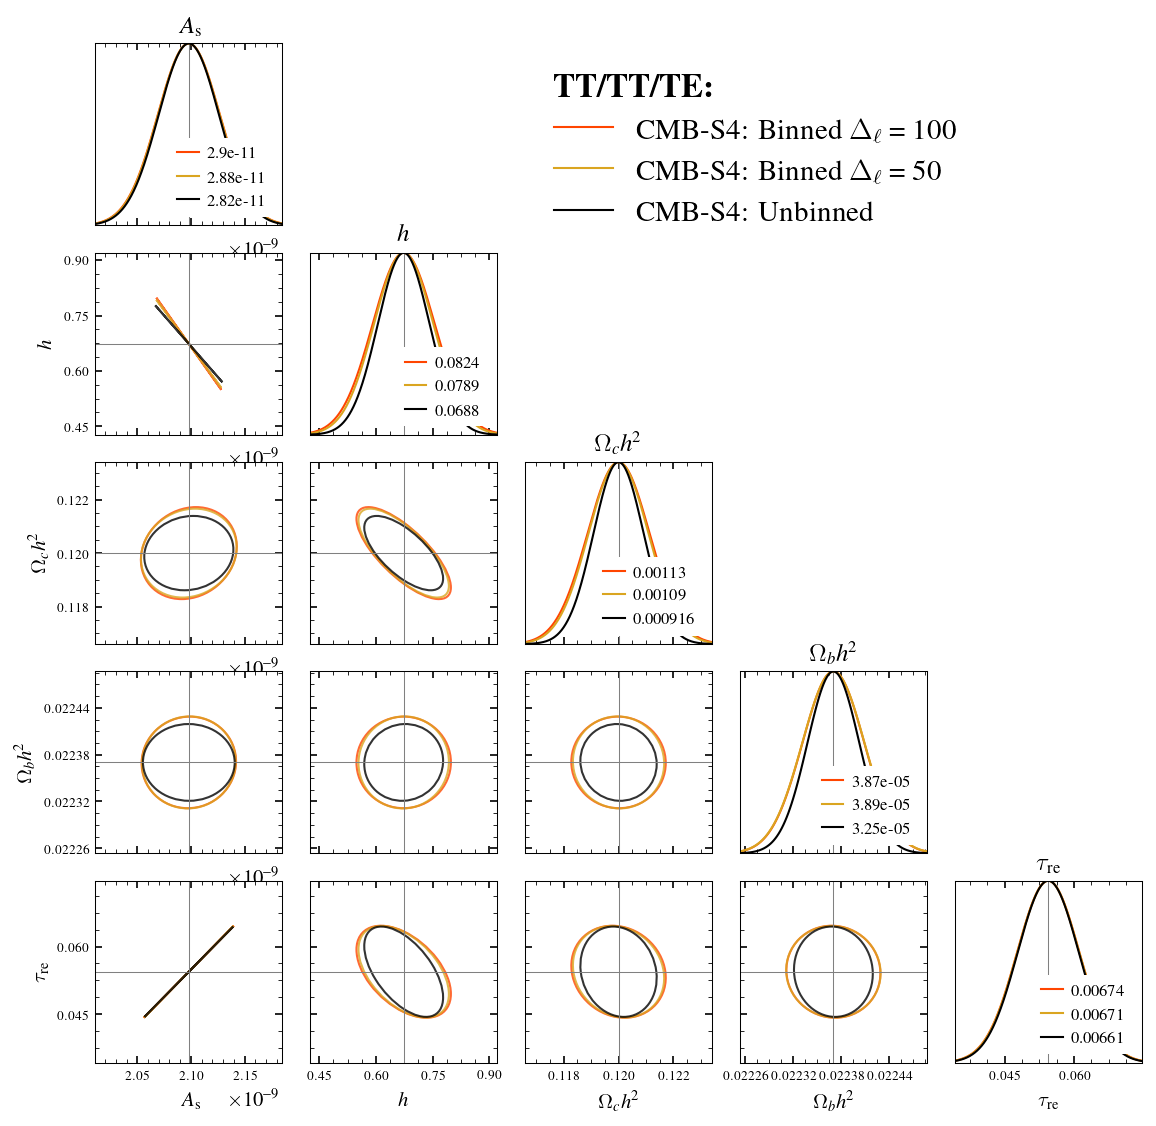

In [32]:
#cmb_param_dict = {'As': 2.196e-9, 'h': 0.6736, 'ns': 0.9649, 'omch2': 0.1200,  'ombh2': 0.02237, 'tau': 0.0544, 'ws': -1.0, 'wa': 0.0}
#cmb_fix_params = ['mnu', 'nrun', 'w0', 'wa']#, 'neff'#, 'wa']
cmb_fix_params = ['mnu', 'nrun', 'w0', 'wa', 'neff']#, 'neff'#, 'wa']
cmb_prior_dic = {'tau': 0.007}
cmb_fisher_dic_to_plot = {}
cmb_color_dic = {}
cmb_ls_dic = {}
fisher_fname_dic = {}
fisher_fname_dic['cmbs4_binned_deltal100'] = 'results/cmb/fisher//cmbs4//cmbs4_cmb_fisher_lensed_scalar_params--As--h--ns--omch2--ombh2--tau--ws--wa--mnu--neff--nrun_lmint300--lminp300--lmaxt3500--lmaxp3500_fsky0.57_deltal100.npy'
fisher_fname_dic['cmbs4_binned_deltal50'] = 'results/cmb/fisher//cmbs4//cmbs4_cmb_fisher_lensed_scalar_params--As--h--ns--omch2--ombh2--tau--ws--wa--mnu--neff--nrun_lmint300--lminp300--lmaxt3500--lmaxp3500_fsky0.57_deltal50.npy'
fisher_fname_dic['cmbs4_unbinned'] = 'results/cmb/fisher//cmbs4//cmbs4_cmb_fisher_lensed_scalar_params--As--h--ns--omch2--ombh2--tau--ws--wa--mnu--neff--nrun_lmint300--lminp300--lmaxt3500--lmaxp3500_fsky0.57.npy'

cmb_color_dic = {}
cmb_color_dic['cmbs4_binned_deltal100'] = 'orangered'
cmb_color_dic['cmbs4_binned_deltal50'] = 'goldenrod'
cmb_color_dic['cmbs4_unbinned'] = 'black'

cmb_ls_dic = {}
cmb_ls_dic['cmbs4_binned_deltal100'] = '-'
cmb_ls_dic['cmbs4_binned_deltal50'] = '-'
cmb_ls_dic['cmbs4_unbinned'] = '-'

cmb_label_dic = {}
cmb_label_dic['cmbs4_binned_deltal100'] = 'CMB-S4: Binned $\Delta_{\ell} = 100$'
cmb_label_dic['cmbs4_binned_deltal50'] = 'CMB-S4: Binned $\Delta_{\ell} = 50$'
cmb_label_dic['cmbs4_unbinned'] = 'CMB-S4: Unbinned'


for keyname in fisher_fname_dic:
    
    print( keyname )
    
    curr_exp_cmb_fisher_fname = fisher_fname_dic[keyname]
    fisher_dic = np.load( curr_exp_cmb_fisher_fname, allow_pickle = True ).item()
    curr_cmb_fisher_mat = fisher_dic['fisher_matrix']
    curr_cmb_params = fisher_dic['params']

    #fix params
    curr_cmb_fisher_mat, curr_cmb_params_mod = misc.fix_params(curr_cmb_fisher_mat, curr_cmb_params, cmb_fix_params)
    
    #add prior
    curr_cmb_fisher_mat = misc.add_prior(curr_cmb_fisher_mat, curr_cmb_params_mod, cmb_prior_dic)
        
    cmb_fisher_dic_to_plot[keyname] = curr_cmb_fisher_mat

#make plot
#desired_params_to_plot = curr_cmb_params_mod
desired_params_to_plot = ['As', 'h', 'omch2', 'ombh2', 'tau']#, 'neff']
fix_axis_range_to_xxsigma = 3 ##None #3
fsval = 12 ##14

##print(cmb_fisher_dic.keys()); sys.exit()

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
assert curr_cmb_fisher_mat.shape[0] == len( curr_cmb_params_mod )
cmb_color_dic, cmb_ls_dic = misc.make_triangle_plot(cmb_fisher_dic_to_plot, tr, tc, curr_cmb_params_mod, param_dict, desired_params_to_plot, fsval = fsval-2, color_dic = cmb_color_dic, ls_dic = cmb_ls_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
ax = subplot(tr, tc, 3)
for keyname in fisher_fname_dic:
    labval, colorval, lsval = cmb_label_dic[keyname], cmb_color_dic[keyname], cmb_ls_dic[keyname]
    plot([], [], color = colorval, ls =lsval, label = r'%s' %(labval))
if add_lensing:
    leg = legend(loc = 2, fontsize = fsval+2, framealpha = 0., title = r'{\bf TT/TT/TE/PP:}', title_fontsize = fsval+4)
else:
    leg = legend(loc = 2, fontsize = fsval+2, framealpha = 0., title = r'{\bf TT/TT/TE:}', title_fontsize = fsval+4)
leg._legend_box.align = 'left'
axis('off')


spt3g_wide
spt3g_wide_withlensing


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 900x600 with 0 Axes>

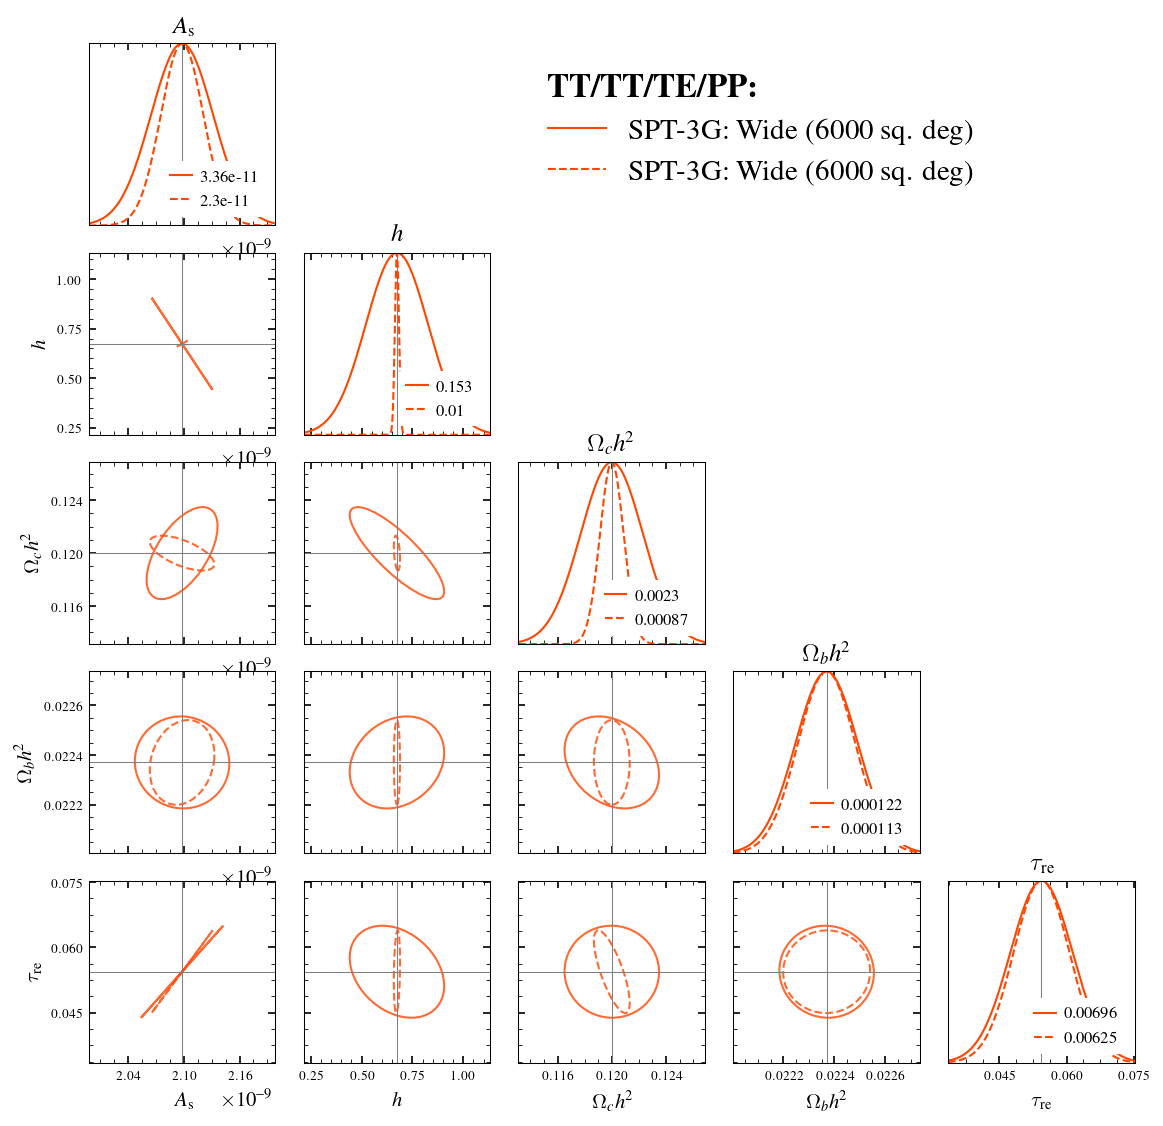

In [113]:
#cmb_param_dict = {'As': 2.196e-9, 'h': 0.6736, 'ns': 0.9649, 'omch2': 0.1200,  'ombh2': 0.02237, 'tau': 0.0544, 'ws': -1.0, 'wa': 0.0}
#cmb_fix_params = ['mnu', 'nrun', 'w0', 'wa']#, 'neff'#, 'wa']
cmb_fix_params = ['mnu', 'nrun', 'w0', 'wa', 'neff']#, 'neff'#, 'wa']
cmb_prior_dic = {'tau': 0.007}
cmb_fisher_dic_to_plot = {}
cmb_color_dic = {}
cmb_ls_dic = {}
for keyname in fisher_fname_dic:
    
    print( keyname )
    
    curr_exp_cmb_fisher_fname = fisher_fname_dic[keyname]
    fisher_dic = np.load( curr_exp_cmb_fisher_fname, allow_pickle = True ).item()
    curr_cmb_fisher_mat = fisher_dic['fisher_matrix']
    curr_cmb_params = fisher_dic['params']

    #fix params
    curr_cmb_fisher_mat, curr_cmb_params_mod = misc.fix_params(curr_cmb_fisher_mat, curr_cmb_params, cmb_fix_params)
    
    #add prior
    curr_cmb_fisher_mat = misc.add_prior(curr_cmb_fisher_mat, curr_cmb_params_mod, cmb_prior_dic)
    
    
    cmb_fisher_dic_to_plot[keyname] = curr_cmb_fisher_mat
    cmb_color_dic[keyname] = exp_dic[expname]['color']
    if keyname.find('_withlensing')>-1:
        cmb_ls_dic[keyname] = '--'
    else:
        cmb_ls_dic[keyname] = '-'

#make plot
#desired_params_to_plot = curr_cmb_params_mod
desired_params_to_plot = ['As', 'h', 'omch2', 'ombh2', 'tau']#, 'neff']
fix_axis_range_to_xxsigma = 3 ##None #3
fsval = 12 ##14

##print(cmb_fisher_dic.keys()); sys.exit()

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
assert curr_cmb_fisher_mat.shape[0] == len( curr_cmb_params_mod )
cmb_color_dic, cmb_ls_dic = misc.make_triangle_plot(cmb_fisher_dic_to_plot, tr, tc, curr_cmb_params_mod, param_dict, desired_params_to_plot, fsval = fsval-2, color_dic = cmb_color_dic, ls_dic = cmb_ls_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
ax = subplot(tr, tc, 3)
for keyname in fisher_fname_dic:
    expname = keyname.split('_with')[0]
    labval, colorval, lsval = exp_dic[expname]['label'], cmb_color_dic[keyname], cmb_ls_dic[keyname]
    plot([], [], color = colorval, ls =lsval, label = r'%s' %(labval))
if add_lensing:
    leg = legend(loc = 2, fontsize = fsval+2, framealpha = 0., title = r'{\bf TT/TT/TE/PP:}', title_fontsize = fsval+4)
else:
    leg = legend(loc = 2, fontsize = fsval+2, framealpha = 0., title = r'{\bf TT/TT/TE:}', title_fontsize = fsval+4)
leg._legend_box.align = 'left'
axis('off')


<Figure size 900x600 with 0 Axes>

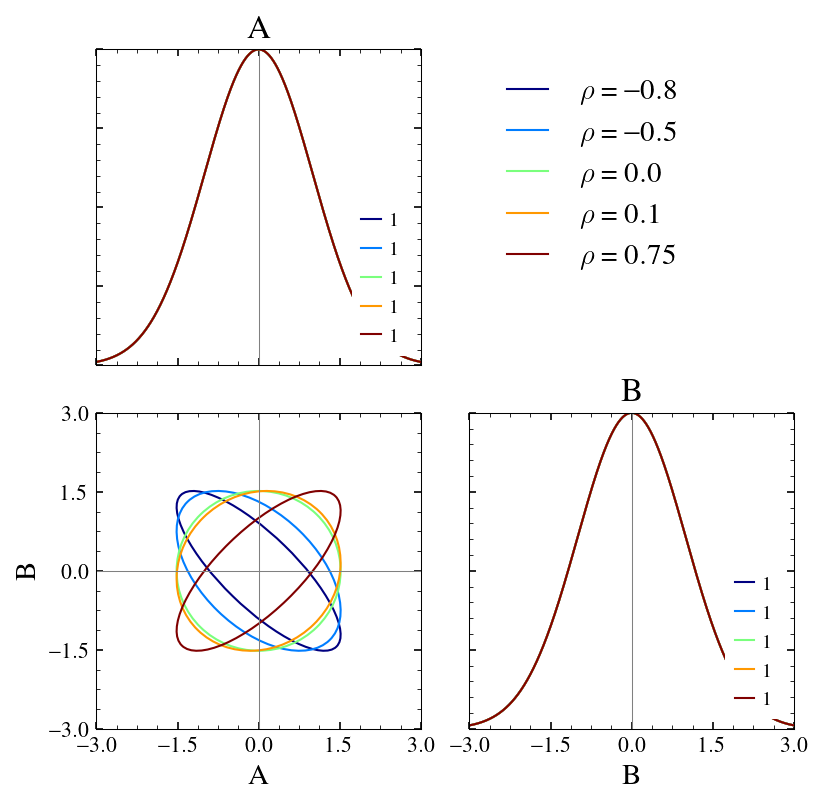

SystemExit: 

/usr/local/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3449: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [27]:
if (1):
    sys.path.append('modules')
    import misc
    tmp_params = ['A', 'B']
    tmp_param_dict = {'A': 0., 'B': 0.}
    var_val_a, var_val_b = 1., 1.
    fisher_dic_to_plot = {}
    color_dic = {}
    #rho_val_arr = [-0.8, -0.5, -0.2, 0., 0.2, 0.5, 0.8]
    rho_val_arr = [-0.8, -0.5, 0., 0.1, 0.75]
    color_arr = [cm.jet(int(d)) for d in np.linspace(0, 255, len(rho_val_arr))]
    for rho_cntr, rho_val in enumerate( rho_val_arr ):
        keyname = 'rho = %s' %(rho_val)
        covar_val_ab = rho_val * np.sqrt( var_val_a * var_val_b )
        tmp_cov_mat = np.asarray( [ [var_val_a, covar_val_ab], [covar_val_ab, var_val_b] ] ).reshape((2,2))
        tmp_f_mat = np.linalg.inv( tmp_cov_mat )
        fisher_dic_to_plot[keyname] = tmp_f_mat
        color_dic[keyname] = color_arr[rho_cntr]

    #make plot
    desired_params_to_plot = tmp_params
    fix_axis_range_to_xxsigma = 3.
    fsval = 14

    clf()
    tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
    figure(figsize = (tr+4, tc+4))
    subplots_adjust(hspace=0.15, wspace = 0.15)
    tmp_color_dic, tmp_ls_dic = misc.make_triangle_plot(fisher_dic_to_plot, tr, tc, tmp_params, tmp_param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

    #legend
    ax = subplot(tr, tc, 2)
    for keyname in fisher_dic_to_plot:
        labval = r'$\%s$' %(keyname)
        plot([], [], color = color_dic[keyname], label = r'%s' %(labval))
    legend(loc = 2, fontsize = fsval, framealpha = 0.)#, title = r'{\bf Errors: %s}' %(lsst_cov_tag_dic[reqd_lsst_tag]))
    axis('off')
    show(); sys.exit()
    
if (1):
    tmp_params = ['omega_m', 'omega_lambda', 'omega_k']
    tmp_param_dict = {'omega_m': 0.27, 'omega_lambda': 0.73, 'omega_k': 0.}
    tmp_f_mat = np.asarray( [ [2376145, 796031, 615114], [796031, 274627, 217371], [615114, 217371, 178014] ] ).reshape((3,3))
    fisher_dic_to_plot = {'test': tmp_f_mat}
    color_dic = {'test': 'black'}

    #make plot
    desired_params_to_plot = tmp_params
    fix_axis_range_to_xxsigma = 3 
    fsval = 14

    clf()
    tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
    figure(figsize = (tr+4, tc+4))
    subplots_adjust(hspace=0.15, wspace = 0.15)
    tmp_color_dic, tmp_ls_dic = misc.make_triangle_plot(fisher_dic_to_plot, tr, tc, tmp_params, tmp_param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

    show()

{\bf Prior(s):} None


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 900x600 with 0 Axes>

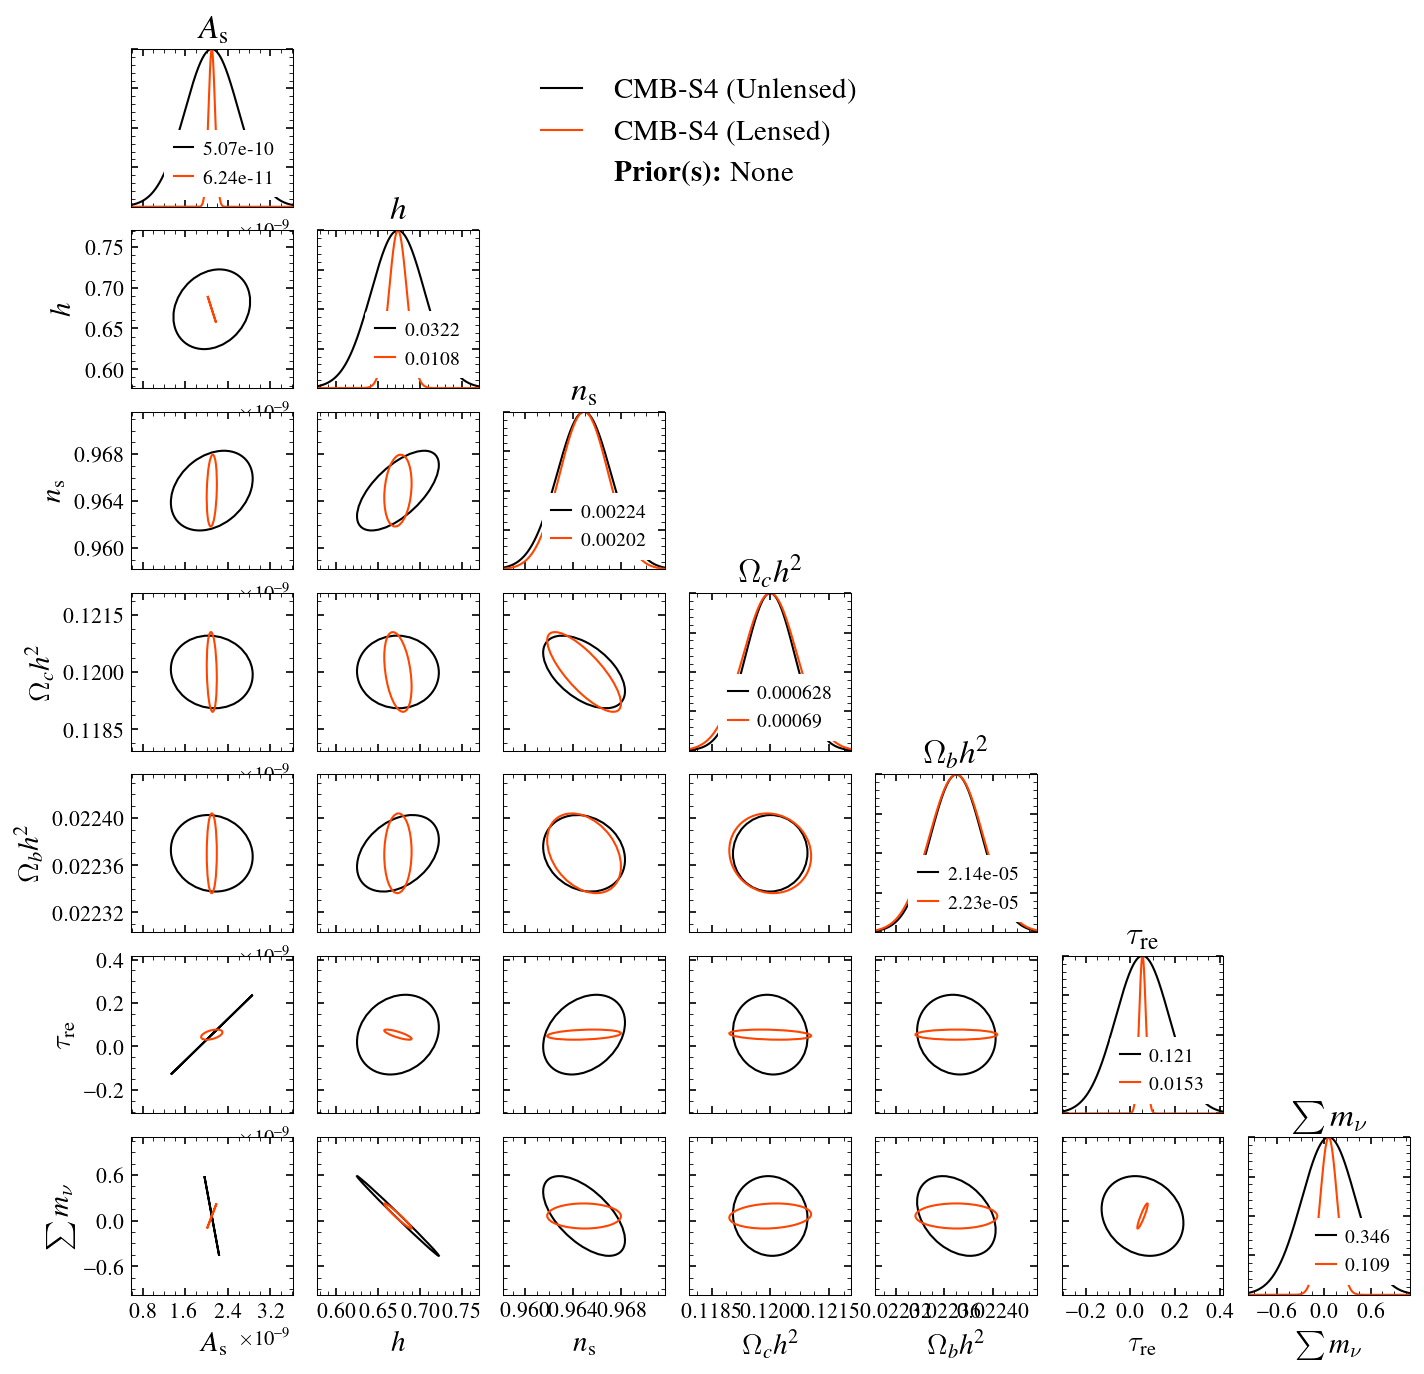

In [19]:
#For avery
cmb_fix_params = ['neff', 'nrun', 'wa', 'ws']
cmb_prior_dic = {}#'tau': 0.002}
tau_prior_str = ''
if cmb_prior_dic is not None:
    for ppp in cmb_prior_dic:
        tau_prior_str = r'%s; %s = %g' %(tau_prior_str, misc.get_latex_param_str(ppp), cmb_prior_dic[ppp])
    tau_prior_str = tau_prior_str.strip(';')
if tau_prior_str == '':
    tau_prior_str = 'None'
tau_prior_str = r'{\bf Prior(s):} %s' %(tau_prior_str)
print( tau_prior_str ); ##sys.exit()

cmb_fisher_dic_to_plot = {}
cmb_color_dic = {}
exp_dic_for_avery = {'cmbs4_ideal_unlensed': {
            'fname': 'results/cmb/cmbs4_ideal/cmbs4_ideal_cmb_fisher_unlensed_scalar_params--As--h--ns--omch2--ombh2--tau--ws--wa--mnu--neff--nrun_lmint30--lminp30--lmaxt3500--lmaxp5000_fsky0.57.npy', 
            'label': 'CMB-S4 (Unlensed)', 
            'color': 'black',
            },
            'cmbs4_ideal_lensed': {
            'fname': 'results/cmb/cmbs4_ideal/cmbs4_ideal_cmb_fisher_lensed_scalar_params--As--h--ns--omch2--ombh2--tau--ws--wa--mnu--neff--nrun_lmint30--lminp30--lmaxt3500--lmaxp5000_fsky0.57.npy', 
            'label': 'CMB-S4 (Lensed)', 
            'color': 'orangered',
            }
           }

for expname in exp_dic_for_avery:    
    curr_exp_cmb_fisher_fname = exp_dic_for_avery[expname]['fname']
    fisher_dic = np.load( curr_exp_cmb_fisher_fname, allow_pickle = True ).item()
    curr_cmb_fisher_mat = fisher_dic['fisher_matrix']
    curr_cmb_params = fisher_dic['params']

    #fix params
    curr_cmb_fisher_mat, curr_cmb_params_mod = misc.fix_params(curr_cmb_fisher_mat, curr_cmb_params, cmb_fix_params)

    #add prior
    curr_cmb_fisher_mat = misc.add_prior(curr_cmb_fisher_mat, curr_cmb_params_mod, cmb_prior_dic)
        
    cmb_fisher_dic_to_plot[expname] = curr_cmb_fisher_mat
    cmb_color_dic[expname] = exp_dic_for_avery[expname]['color']

#make plot
desired_params_to_plot = curr_cmb_params_mod
fix_axis_range_to_xxsigma = 3 ##None #3
fsval = 14

##print(cmb_fisher_dic.keys()); sys.exit()

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
cmb_color_dic, cmb_ls_dic = misc.make_triangle_plot(cmb_fisher_dic_to_plot, tr, tc, curr_cmb_params_mod, param_dict, desired_params_to_plot, fsval = fsval, color_dic = cmb_color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
ax = subplot(tr, tc, 3)
for expname in exp_dic_for_avery:
    labval, colorval = exp_dic_for_avery[expname]['label'], exp_dic_for_avery[expname]['color']
    plot([], [], color = colorval, label = r'%s' %(labval))
plot([], [], color = 'w', label = r'%s' %(tau_prior_str))

#figtext(0.4, 0.8, tau_prior_str, fontsize = 14)
legend(loc = 2, fontsize = fsval, framealpha = 0.)#, title = r'{\bf Errors: %s}' %(lsst_cov_tag_dic[reqd_lsst_tag]))
axis('off')


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 900x600 with 0 Axes>

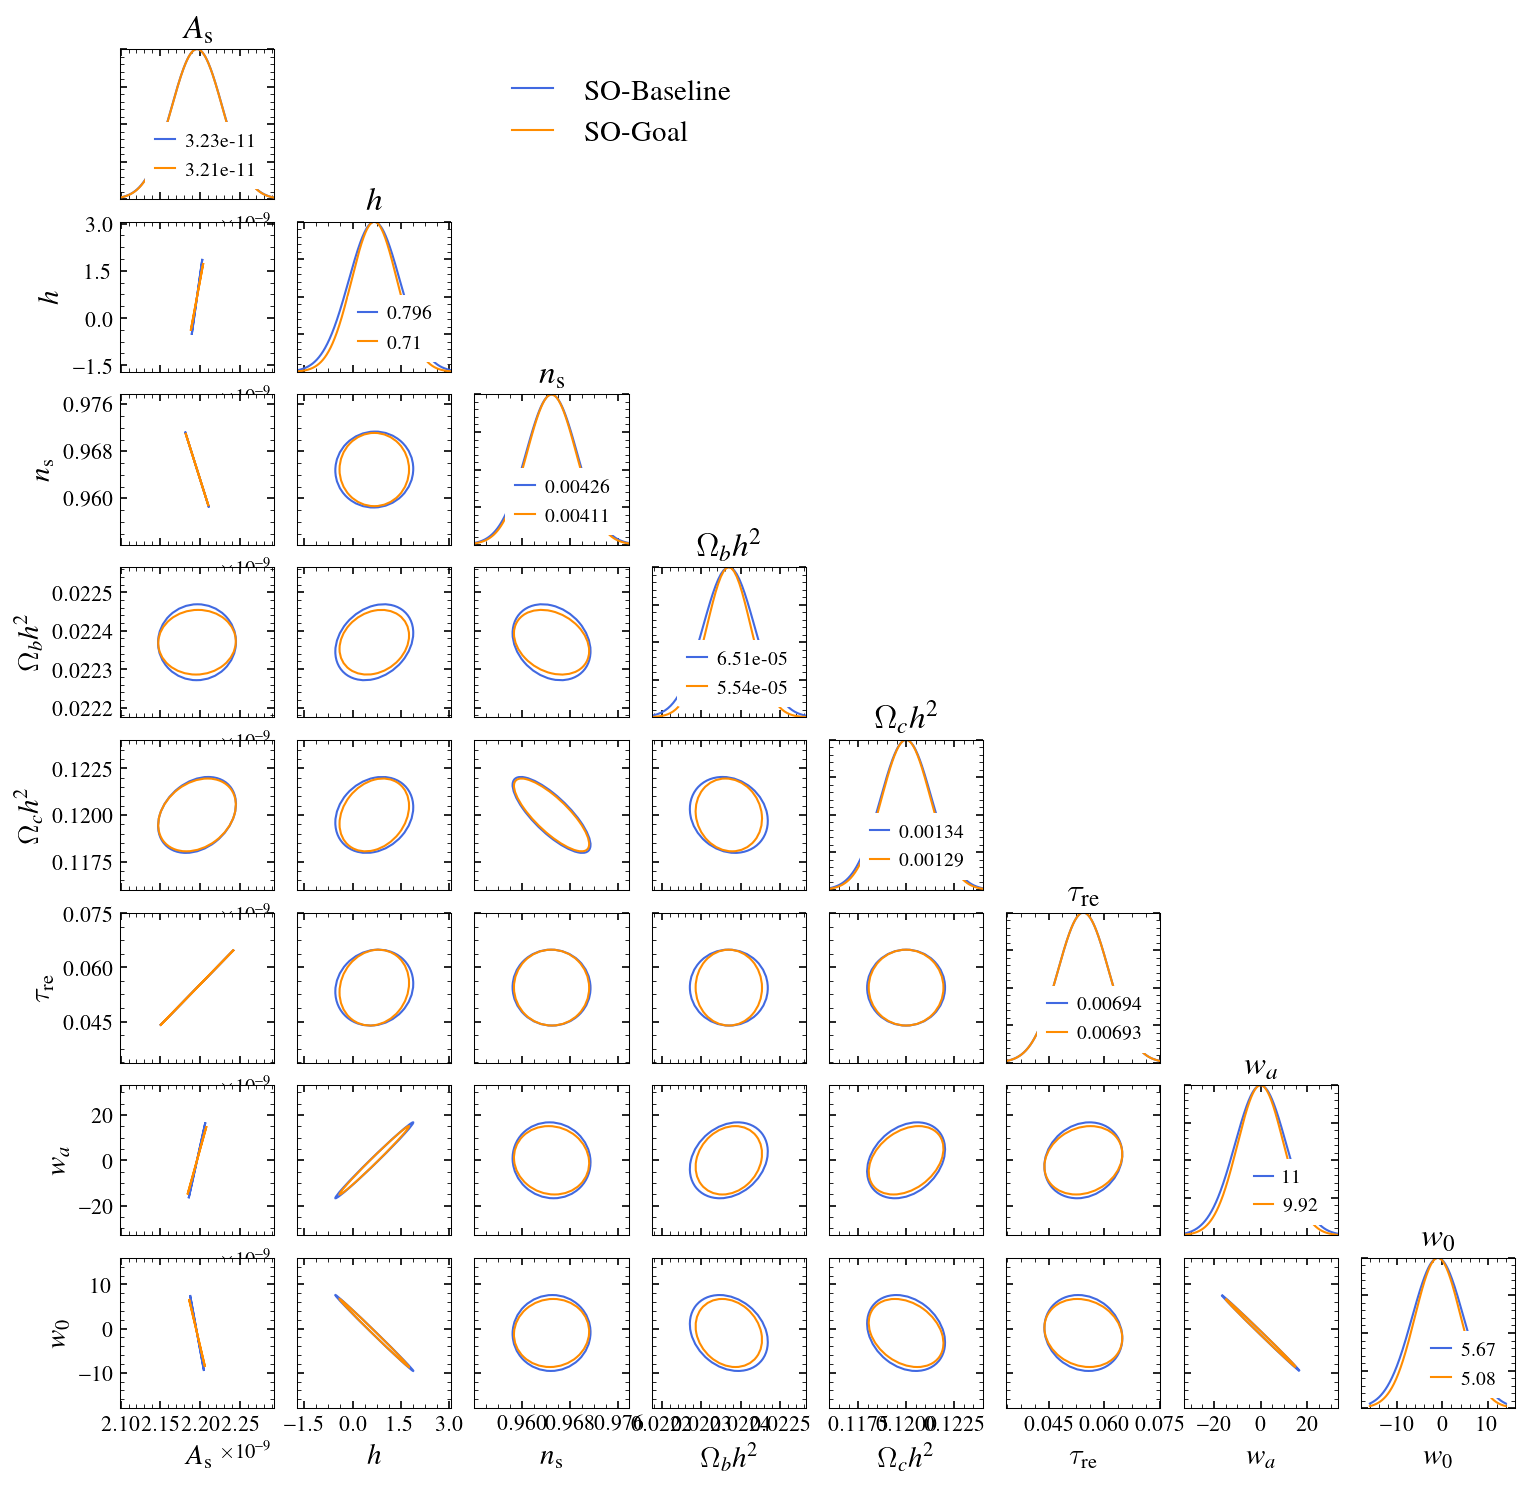

In [18]:
cmb_param_dict = {'As': 2.196e-9, 'h': 0.6736, 'ns': 0.9649, 'omch2': 0.1200,  'ombh2': 0.02237, 'tau': 0.0544, 'ws': -1.0, 'wa': 0.0}

import glob
cmb_fisher_fd = 'data/cmb_fisher/'
cmb_expname_dic = {'sobaseline': ['SO-Baseline', 'royalblue'], 'sogoal': ['SO-Goal', 'darkorange'] }

cmb_fix_params = ['mnu', 'neff', 'nrun']#, 'As']
cmb_prior_dic = {'tau': 0.007}

cmb_color_dic = {}
cmb_fisher_dic = {}
for expname in cmb_expname_dic:
    cmb_fisher_fname_searchstr = '%s/%s_*' %(cmb_fisher_fd, expname)
    cmb_fisher_fname = glob.glob( cmb_fisher_fname_searchstr )[0]

    res_dic = np.load(cmb_fisher_fname, allow_pickle = True).item()
    
    cmb_param_names = res_dic['param_names']
    curr_cmb_fisher_mat = res_dic['F_mat']
    
    #fix params
    curr_cmb_fisher_mat, cmb_param_names = misc.fix_params(curr_cmb_fisher_mat, cmb_param_names, cmb_fix_params)
    
    #add prior
    curr_cmb_fisher_mat = misc.add_prior(curr_cmb_fisher_mat, cmb_param_names, cmb_prior_dic)
    
    
    cmb_fisher_dic[expname] = curr_cmb_fisher_mat
    cmb_color_dic[expname] = cmb_expname_dic[expname][1]

#make plot
desired_params_to_plot = cmb_param_names
color_dic = {0: 'black'}
fix_axis_range_to_xxsigma = 3 ##None #3
fsval = 14

##print(cmb_fisher_dic.keys()); sys.exit()

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
cmb_color_dic, cmb_ls_dic = misc.make_triangle_plot(cmb_fisher_dic, tr, tc, cmb_param_names, cmb_param_dict, desired_params_to_plot, fsval = fsval, color_dic = cmb_color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
ax = subplot(tr, tc, 3)
for expname in cmb_expname_dic:
    labval, colorval = cmb_expname_dic[expname]
    plot([], [], color = colorval, label = r'%s' %(labval))

legend(loc = 2, fontsize = fsval, framealpha = 0.)#, title = r'{\bf Errors: %s}' %(lsst_cov_tag_dic[reqd_lsst_tag]))
axis('off')


# SNIa Fisher now

(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 900x600 with 0 Axes>

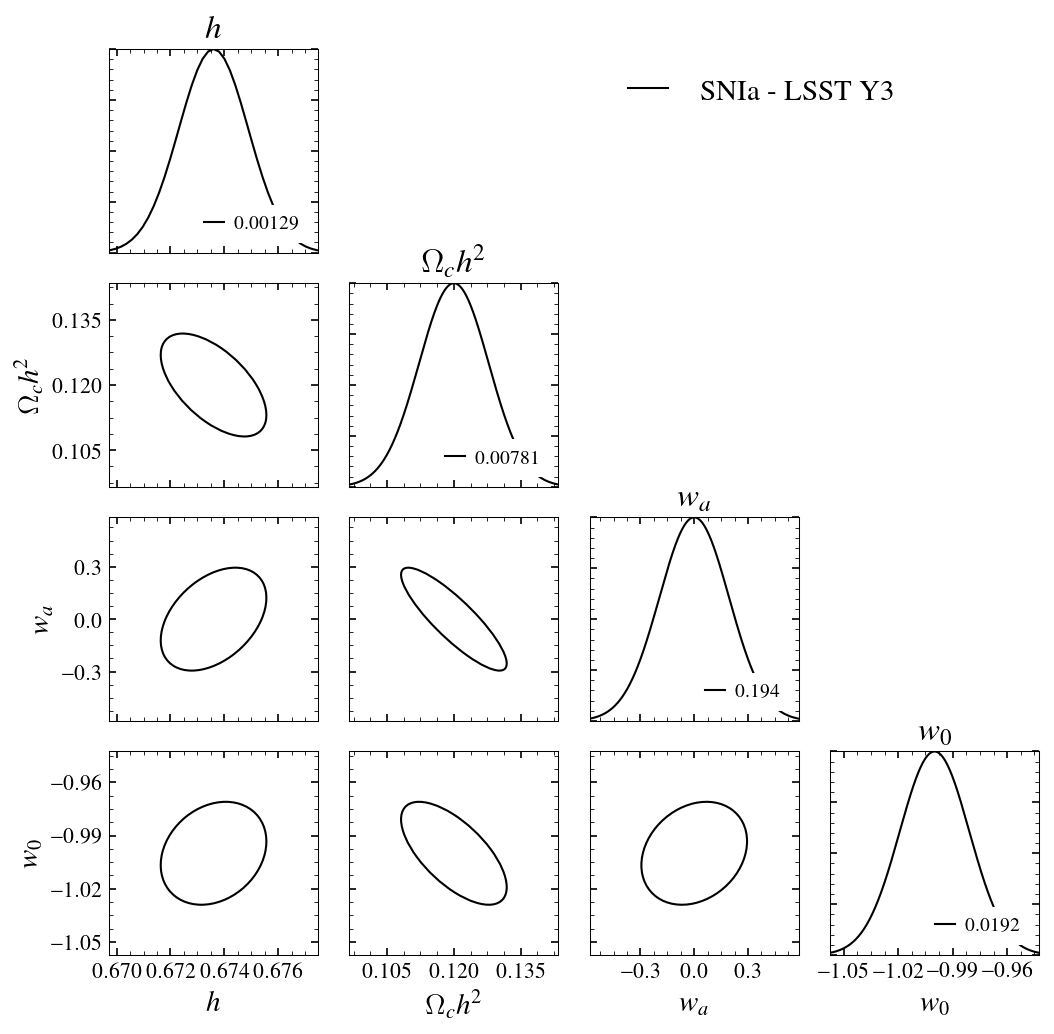

In [63]:
sne_result_fname = 'data/lsst_SNe/fisher_sne_tmp.npy'
sne_result_dic = np.load(sne_result_fname, allow_pickle=True).item()

sne_param_names = sne_result_dic['params']
sne_param_dict = sne_result_dic['param_dict']
sne_fisher_dic_all = sne_result_dic['fisher']

reqd_sne_lsst_tag = 8
reqd_zbin_ind = 2 ##3

sne_fisher_dic = {'snia_lsst_y3': sne_fisher_dic_all[reqd_sne_lsst_tag][reqd_zbin_ind]}
sne_color_dic = {'snia_lsst_y3': 'black'}
sne_labval_dic = {'snia_lsst_y3': 'SNIa - LSST Y3'}
##print(sne_fisher_dic['snia_lsst_y3'].keys()); sys.exit()

#make plot
desired_params_to_plot = sne_param_names
fix_axis_range_to_xxsigma = 3 ##None #3
fsval = 14

##print(cmb_fisher_dic.keys()); sys.exit()

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
cmb_color_dic, cmb_ls_dic = misc.make_triangle_plot(sne_fisher_dic, tr, tc, sne_param_names, sne_param_dict, desired_params_to_plot, fsval = fsval, color_dic = sne_color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
ax = subplot(tr, tc, 3)
for expname in sne_color_dic:
    labval, colorval = sne_labval_dic[expname], sne_color_dic[expname]
    plot([], [], color = colorval, label = r'%s' %(labval))

legend(loc = 2, fontsize = fsval, framealpha = 0.)#, title = r'{\bf Errors: %s}' %(lsst_cov_tag_dic[reqd_lsst_tag]))
axis('off')


# Combine fisher matrices now

/usr/local/lib/python3.9/site-packages/numpy/lib/function_base.py:804: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, order=order, subok=subok, copy=True)


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 900x600 with 0 Axes>

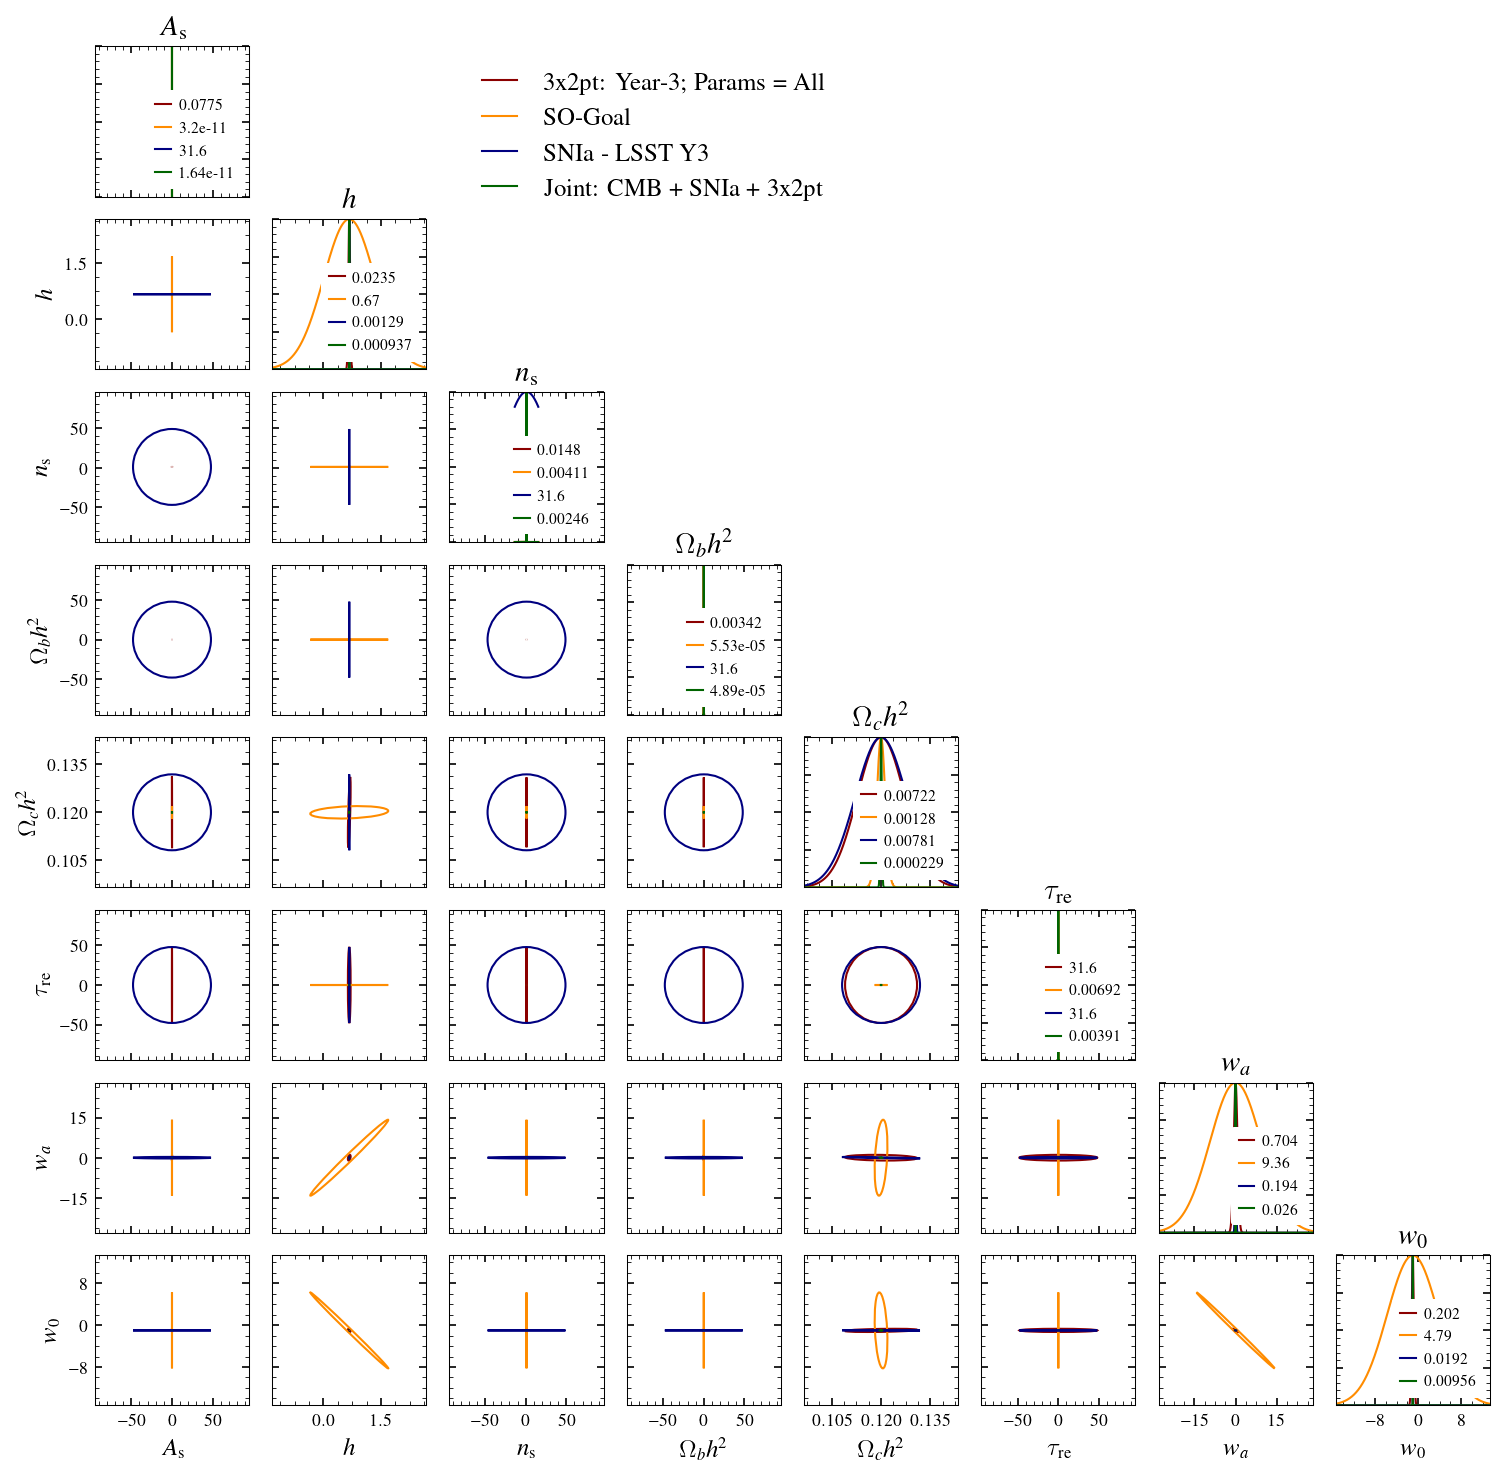

In [67]:
#lsst
which_lsst_param_type = 'all'
which_keyname = 'csw-y3'
##print(lsst_3x2pt_fisher_dic.keys())
lsst_param_names, parent_lsst_fisher_dic, lsst_color_dic = lsst_3x2pt_fisher_dic[which_lsst_param_type]
lsst_fisher_mat = parent_lsst_fisher_dic[which_keyname]

#cmb
##which_cmb_exp = 'sobaseline'
which_cmb_exp = 'sogoal'
cmb_fisher_mat = cmb_fisher_dic[which_cmb_exp]

#SNia
which_sne_expname = 'snia_lsst_y3'
sne_param_names = sne_param_names
sne_fisher_mat = sne_fisher_dic[which_sne_expname]

#combine now
F_mat_arr = [lsst_fisher_mat, cmb_fisher_mat, sne_fisher_mat]
param_names_arr = [lsst_param_names, cmb_param_names, sne_param_names]
combined_F_mat, combined_param_names, F_mat_mod_arr = misc.combine_fisher( F_mat_arr, param_names_arr )
##print(len(combined_param_names)); sys.exit()

#make plot
desired_params_to_plot = cmb_param_names #combined_param_names
fix_axis_range_to_xxsigma = 3. ##None ##3 ##None #3
fsval = 12

combined_param_dict = {}
for ppp in combined_param_names:
    if ppp in cmb_param_dict:
        combined_param_dict[ppp] = cmb_param_dict[ppp]
    elif ppp in lsst_param_dict:
        combined_param_dict[ppp] = lsst_param_dict[ppp]

##print(combined_param_dict); sys.exit()

combined_fisher_dic = {}
combined_fisher_dic['LSST'] = F_mat_mod_arr[0]
combined_fisher_dic[which_cmb_exp] = F_mat_mod_arr[1]
combined_fisher_dic[which_sne_expname] = F_mat_mod_arr[2]
combined_fisher_dic['Joint'] = combined_F_mat

combined_color_dic = {}
combined_color_dic['LSST'] = 'darkred'
combined_color_dic[which_cmb_exp] = 'darkorange'
combined_color_dic[which_sne_expname] = 'navy'
combined_color_dic['Joint'] = 'darkgreen'

clf()
#desired_params_to_plot = ['omch2', 'ombh2', 'wa', 'ws']
fsval = 12
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
combined_color_dic, combined_ls_dic = misc.make_triangle_plot(combined_fisher_dic, tr, tc, combined_param_names, combined_param_dict, desired_params_to_plot, fsval = fsval, color_dic = combined_color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
ax = subplot(tr, tc, 3)
for expname in combined_fisher_dic:
    if expname == 'LSST':
        labval = get_lsst_label(which_lsst_param_type, which_keyname)
    elif expname == which_cmb_exp:
        labval = cmb_expname_dic[expname][0]
    elif expname == which_sne_expname:
        labval = sne_labval_dic[expname]
    else:
        labval = r'Joint: CMB + SNIa + 3x2pt'
        
    plot([], [], color = combined_color_dic[expname], label = r'%s' %(labval))

legend(loc = 2, fontsize = fsval, framealpha = 0.)#, title = r'{\bf Errors: %s}' %(lsst_cov_tag_dic[reqd_lsst_tag]))
axis('off')


# Bar plots

In [68]:
desired_param_arr = ['h', 'omch2', 'ws', 'wa']
pl_dic = {}
for desired_param in desired_param_arr:
    pl_dic[desired_param] = {}
    for curr_datset in combined_fisher_dic:
        if curr_datset == 'LSST':
            labval = get_lsst_label(which_lsst_param_type, which_keyname)
        elif curr_datset == which_cmb_exp:
            labval = cmb_expname_dic[curr_datset][0]
        elif curr_datset == which_sne_expname:
            labval = sne_labval_dic[curr_datset]
        else:
            labval = r'Joint: CMB + SNIa + 3x2pt'
        curr_F_mat = combined_fisher_dic[curr_datset]

        curr_sigma = misc.get_sigma_of_a_parameter(curr_F_mat, combined_param_names, [desired_param])[desired_param]
        pl_dic[desired_param][curr_datset] = curr_sigma

        print(curr_datset, labval, desired_param, curr_sigma)
    print('\n\n')

LSST 3x2pt: Year-3; Params = All h 0.023544224793473248
sogoal SO-Goal h 0.6698164750711179
snia_lsst_y3 SNIa - LSST Y3 h 0.0012936657679405313
Joint Joint: CMB + SNIa + 3x2pt h 0.0009374579944064746



LSST 3x2pt: Year-3; Params = All omch2 0.007216529008405794
sogoal SO-Goal omch2 0.0012779243012324515
snia_lsst_y3 SNIa - LSST Y3 omch2 0.007813696869252953
Joint Joint: CMB + SNIa + 3x2pt omch2 0.00022872049422901383



LSST 3x2pt: Year-3; Params = All ws 0.2023292750114729
sogoal SO-Goal ws 4.792014347799398
snia_lsst_y3 SNIa - LSST Y3 ws 0.01916939901288681
Joint Joint: CMB + SNIa + 3x2pt ws 0.009560690620714567



LSST 3x2pt: Year-3; Params = All wa 0.704327412367007
sogoal SO-Goal wa 9.357229778131439
snia_lsst_y3 SNIa - LSST Y3 wa 0.19428787345363543
Joint Joint: CMB + SNIa + 3x2pt wa 0.026014043825286076





h LSST 0 0.023544224793473248
h sogoal 1.0 0.6698164750711179
h snia_lsst_y3 2.0 0.0012936657679405313
h Joint 3.0 0.0009374579944064746



omch2 LSST 5.0 0.007216529008405794
omch2 sogoal 6.0 0.0012779243012324515
omch2 snia_lsst_y3 7.0 0.007813696869252953
omch2 Joint 8.0 0.00022872049422901383



ws LSST 10.0 0.2023292750114729
ws sogoal 11.0 4.792014347799398
ws snia_lsst_y3 12.0 0.01916939901288681
ws Joint 13.0 0.009560690620714567



wa LSST 15.0 0.704327412367007
wa sogoal 16.0 9.357229778131439
wa snia_lsst_y3 17.0 0.19428787345363543
wa Joint 18.0 0.026014043825286076





<Figure size 900x600 with 0 Axes>

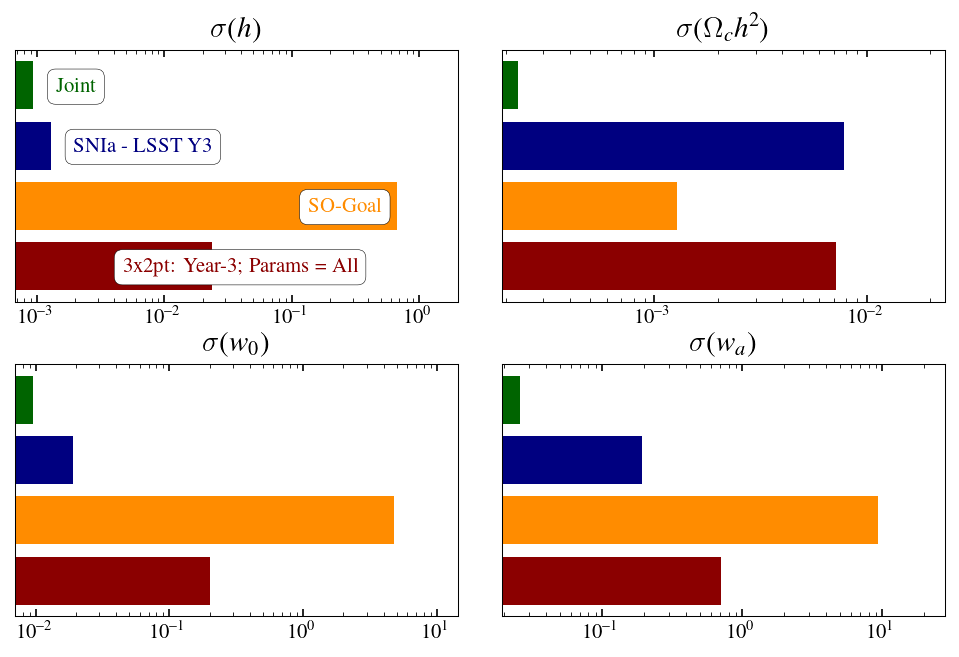

SystemExit: 

/usr/local/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3449: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [69]:
clf()
fsval = 14
figure(figsize = (8., 5.))
tr, tc = 2, 2
yloc = 0
width = 1.
subplots_adjust(wspace = 0.1, hspace = 0.25)
for desired_param_cntr, desired_param in enumerate( desired_param_arr ):
    ax = subplot(tr, tc, desired_param_cntr+1, xscale = 'log')
    maxval = 0.
    for curr_datset in combined_fisher_dic:
        if curr_datset == 'LSST':
            labval = get_lsst_label(which_lsst_param_type, which_keyname)
            textloc_mul = 0.2
        elif curr_datset == which_cmb_exp:
            labval = cmb_expname_dic[curr_datset][0]
            textloc_mul = 0.2
        elif curr_datset == which_sne_expname:
            labval = sne_labval_dic[curr_datset]
            textloc_mul = 1.5
        else:
            labval = r'Joint'#: CMB + SNIa + 3x2pt'
            textloc_mul = 1.5
        
        colorval = combined_color_dic[curr_datset]
        curr_sigma = pl_dic[desired_param][curr_datset]
        print(desired_param, curr_datset, yloc, curr_sigma)
        barh(yloc, curr_sigma, color = colorval)
        if desired_param_cntr == 0:            
            text( curr_sigma*textloc_mul, yloc-0.1, r'%s' %(labval), fontsize = fsval-4, color = colorval, \
                 bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4', lw = 0.25))
        yloc += width
        maxval = max(maxval, curr_sigma)
    xlim(None, maxval * 3.)
    tick_params(axis = 'y', which = 'both', left = False, right = False)
    yticks([])
    title(r'$\sigma$(%s)' %(misc.get_latex_param_str(desired_param)), fontsize = fsval)
    yloc += width
    print('\n\n')
show(); sys.exit()
        
